# Simple Logistic Regression Workbench

This notebook creates a capped dataset from `obs100000LP.csv`, keeping every `(level_t, learn_cnt)` combination that occurs more than 1,000 times and randomly retaining 1,000 observations for each qualifying combination.

The capped dataset is then used for the existing 66/33 stratified train/test logistic-regression workflow. The validation section reports `level_t`, `learn_cnt`, number of appearances, empirical success rate, and model success rate for every combination present in the validation set.


## 1. Imports

Only the small set of packages needed for loading data, training the model, and reporting results are imported here.

In [8]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
import numpy as np

## 2. Configuration

The train/test split is fixed at 66/33. The model uses `level_t` and `learn_cnt`. The notebook first creates `obs100000LP_capped1000.csv` from `obs100000LP.csv` and then trains the model on the capped dataset.


In [9]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "output").exists():
            return candidate
        if (candidate / "python" / "output").exists():
            return candidate / "python"
    raise FileNotFoundError("Could not find the python/output folder.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "output"

# SOURCE_DATASET_NAME = "obs100000LP"
# CAPPED_DATASET_NAME = "obs100000LP_capped2000"
SOURCE_DATASET_NAME = "obs100000MP"
CAPPED_DATASET_NAME = "obs100000MP_capped2000"
CAPPED_LIMIT = 2000

TARGET_COLUMN = "a_t"
BASE_FEATURE_COLUMNS = ["level_t", "learn_cnt"]
OPTIONAL_LAG_FEATURE_COLUMNS = ["a_t_minus_5", "a_t_minus_4", "a_t_minus_3", "a_t_minus_2", "a_t_minus_1"]
    
USE_LAG_FEATURES = False
FEATURE_COLUMNS = BASE_FEATURE_COLUMNS + OPTIONAL_LAG_FEATURE_COLUMNS if USE_LAG_FEATURES else BASE_FEATURE_COLUMNS

RANDOM_SEED = 42
TEST_SIZE = 0.33

print(f"Project root: {PROJECT_ROOT}")
print(f"Source dataset: {SOURCE_DATASET_NAME}.csv")
print(f"Capped dataset: {CAPPED_DATASET_NAME}.csv")


Project root: C:\Users\valdr\source\repos\DissertationRepo\python
Source dataset: obs100000MP.csv
Capped dataset: obs100000MP_capped2000.csv


## 3. Data Loading and Capping

The source CSV is loaded first. Every `(level_t, learn_cnt)` combination is counted. Only combinations occurring strictly more than 1,000 times are retained, and exactly 1,000 observations are randomly sampled from each qualifying combination using the fixed random seed. The resulting dataset is saved as `obs100000LP_capped1000.csv` or `obs100000MP_capped1000.csv` depending on the source dataset used.


In [10]:
def load_dataset(csv_path: Path) -> pd.DataFrame:
    frame = pd.read_csv(csv_path)
    required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
    missing_columns = [column for column in required_columns if column not in frame.columns]
    if missing_columns:
        raise ValueError(f"Missing columns in {csv_path.name}: {', '.join(missing_columns)}")
    return frame[required_columns].sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


source_path = DATA_DIR / f"{SOURCE_DATASET_NAME}.csv"
if not source_path.exists():
    raise FileNotFoundError(f"Could not find source dataset: {source_path}")

source_frame = pd.read_csv(source_path)
required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
missing_columns = [column for column in required_columns if column not in source_frame.columns]
if missing_columns:
    raise ValueError(f"Missing columns in {source_path.name}: {', '.join(missing_columns)}")

# Count every level_t / learn_cnt combination.
combination_counts = (
    source_frame
    .groupby(["level_t", "learn_cnt"], dropna=False)
    .size()
    .reset_index(name="combination_count")
)

# Keep only combinations occurring MORE THAN 1000 times.
qualifying_combinations = combination_counts.loc[
    combination_counts["combination_count"] > CAPPED_LIMIT,
    ["level_t", "learn_cnt"]
]

print(f"Found {len(qualifying_combinations)} combinations occurring more than {CAPPED_LIMIT} times.")

# Keep observations belonging to qualifying combinations.
capped_frame = source_frame.merge(
    qualifying_combinations,
    on=["level_t", "learn_cnt"],
    how="inner",
)[required_columns]

# Randomly retain exactly 1000 observations per qualifying combination.
capped_frame = (
    capped_frame
    .groupby(["level_t", "learn_cnt"], group_keys=False)
    .sample(n=CAPPED_LIMIT, random_state=RANDOM_SEED)
    .sort_values(["level_t", "learn_cnt"])
    .reset_index(drop=True)
)

capped_path = DATA_DIR / f"{CAPPED_DATASET_NAME}.csv"
capped_frame.to_csv(capped_path, index=False)

print(f"Created {CAPPED_DATASET_NAME}.csv with {len(capped_frame):,} rows.")
display(capped_frame.head())

# The model is deliberately trained only on the newly created capped dataset.
datasets = {
    CAPPED_DATASET_NAME: load_dataset(capped_path)
}

for name, frame in datasets.items():
    print(f"{name}: {frame.shape[0]:,} rows x {frame.shape[1]} columns")


Found 20 combinations occurring more than 2000 times.
Created obs100000MP_capped2000.csv with 40,000 rows.


,level_t,learn_cnt,a_t
0,1,0,0
1,1,0,0
2,1,0,1
3,1,0,1
4,1,0,1


obs100000MP_capped2000: 40,000 rows x 3 columns


## 4. Model Training

A single pipeline is used for the capped dataset: median imputation, standardisation, and logistic regression. The split is 67% training and 33% validation, corresponding to the requested 66/33 split using `TEST_SIZE = 0.33`.


In [11]:
class PerLevelLogisticRegression:
    """Wraps one LogisticRegression per level behind a single predict/predict_proba
    interface -- drop-in replacement anywhere the notebook expects a single model.
    """

    def __init__(self, per_level_models: dict):
        self.per_level_models = per_level_models
        self.classes_ = np.array([0, 1])

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=["level_t", "learn_cnt"])

        proba_class1 = np.zeros(len(X))

        for level, sub_model in self.per_level_models.items():
            mask = (X["level_t"] == level).values

            if mask.any():
                proba_class1[mask] = sub_model.predict_proba(
                    X.loc[mask, ["learn_cnt"]]
                )[:, 1]

        return np.column_stack([1 - proba_class1, proba_class1])

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def calculate_metrics(y_true, y_pred) -> dict[str, Any]:
    """Calculate classification metrics including the confusion matrix."""

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "specificity": (
            tn / (tn + fp)
            if (tn + fp)
            else 0.0
        ),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def train_and_evaluate(frame: pd.DataFrame) -> dict[str, Any]:

    # ---------------------------------------------------------
    # Train/test split
    # ---------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        frame[FEATURE_COLUMNS],
        frame[TARGET_COLUMN],
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=(
            frame[TARGET_COLUMN]
            if frame[TARGET_COLUMN].nunique() > 1
            else None
        ),
    )

    # ---------------------------------------------------------
    # Train one logistic regression model per level
    # ---------------------------------------------------------
    per_level_models = {}

    for level in sorted(X_train["level_t"].unique()):

        mask = X_train["level_t"] == level

        per_level_models[level] = LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_SEED
        ).fit(
            X_train.loc[mask, ["learn_cnt"]],
            y_train[mask]
        )

    # ---------------------------------------------------------
    # Combined model wrapper
    # ---------------------------------------------------------
    model = PerLevelLogisticRegression(per_level_models)

    # Predictions for the complete validation set
    y_pred = model.predict(X_test)

    # ---------------------------------------------------------
    # Combined metrics
    # ---------------------------------------------------------
    combined_metrics = calculate_metrics(
        y_test,
        y_pred
    )

    # ---------------------------------------------------------
    # Per-level metrics
    # ---------------------------------------------------------
    level_metrics = {}

    for level in sorted(X_test["level_t"].unique()):

        mask = X_test["level_t"] == level

        level_y_test = y_test.loc[mask]
        level_y_pred = y_pred[mask.values]

        level_metrics[level] = {
            "rows": int(mask.sum()),
            **calculate_metrics(
                level_y_test,
                level_y_pred
            )
        }

    return {
        "model": model,
        "X_test": X_test.reset_index(drop=True),
        "y_test": y_test.reset_index(drop=True),
        "y_pred": pd.Series(y_pred).reset_index(drop=True),

        # Combined metrics
        "metrics": combined_metrics,

        # Metrics broken down by level
        "level_metrics": level_metrics,
    }


def summarize_result(
    dataset_name: str,
    frame: pd.DataFrame
) -> tuple[dict[str, Any], list[dict[str, Any]]]:

    result = train_and_evaluate(frame)

    rows = []

    # ---------------------------------------------------------
    # Per-level results
    # ---------------------------------------------------------
    for level, metrics in result["level_metrics"].items():

        rows.append({
            "dataset": dataset_name,
            "level": level,
            **metrics,
        })

    # ---------------------------------------------------------
    # Combined result
    # ---------------------------------------------------------
    rows.append({
        "dataset": dataset_name,
        "level": "Combined",
        "rows": len(result["X_test"]),
        **result["metrics"],
    })

    return result, rows


# =============================================================
# Train and evaluate all datasets
# =============================================================

training_results = {}
results_rows = []

for dataset_name, frame in datasets.items():

    result, summary_rows = summarize_result(
        dataset_name,
        frame
    )

    training_results[dataset_name] = result
    results_rows.extend(summary_rows)


# =============================================================
# Final results table
# =============================================================

results_df = (
    pd.DataFrame(results_rows)
    .sort_values(
        ["dataset", "level"],
        key=lambda s: (
            s.map({
                "Combined": 99
            }).fillna(s)
            if s.name == "level"
            else s
        )
    )
    .reset_index(drop=True)
)

display(results_df)


,dataset,level,rows,accuracy,precision,recall,f1_score,specificity,tn,fp,fn,tp
0,obs100000MP_capped2000,1,2655,0.807533,0.807533,1.0,0.893519,0.0,0,511,0,2144
1,obs100000MP_capped2000,2,4619,0.734142,0.734142,1.0,0.846692,0.0,0,1228,0,3391
2,obs100000MP_capped2000,3,5926,0.656767,0.656767,1.0,0.792829,0.0,0,2034,0,3892
3,obs100000MP_capped2000,Combined,13200,0.714167,0.714167,1.0,0.833252,0.0,0,3773,0,9427


## 5. Results Details

This section prints the most important validation results for each dataset, including the confusion matrix counts and the classification report.

In [12]:
def show_metrics(dataset_name: str, result: dict[str, Any]) -> None:
    metrics = result["metrics"]
    print(f"Dataset: {dataset_name}")
    print(f"TN={metrics['tn']}  FP={metrics['fp']}  FN={metrics['fn']}  TP={metrics['tp']}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 score: {metrics['f1_score']:.4f}")
    print(f"Specificity: {metrics['specificity']:.4f}")
    print(classification_report(result["y_test"], result["y_pred"], zero_division=0))
    print("-" * 60)


for dataset_name, result in training_results.items():
    show_metrics(dataset_name, result)

Dataset: obs100000MP_capped2000
TN=0  FP=3773  FN=0  TP=9427
Accuracy: 0.7142
Precision: 0.7142
Recall: 1.0000
F1 score: 0.8333
Specificity: 0.0000
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3773
           1       0.71      1.00      0.83      9427

    accuracy                           0.71     13200
   macro avg       0.36      0.50      0.42     13200
weighted avg       0.51      0.71      0.60     13200

------------------------------------------------------------


## 6. Validation Combination Table and Plots

The validation table groups the held-out observations by `(level_t, learn_cnt)`. `empirical_success_rate` is the observed mean of `a_t`, while `model_success_rate` is the mean predicted probability of class 1 for that combination.


,level_t,learn_cnt,number_of_appearances,empirical_success_rate,model_success_rate
0,1,0,676,0.687870,0.697263
1,1,1,647,0.814529,0.780081
2,1,2,652,0.851227,0.845271
3,1,3,680,0.877941,0.893768
4,2,0,669,0.593423,0.657341
5,2,1,679,0.667158,0.688889
6,2,2,648,0.756173,0.718774
7,2,3,664,0.759036,0.746844
8,2,4,638,0.769592,0.772997
9,2,5,637,0.808477,0.797181


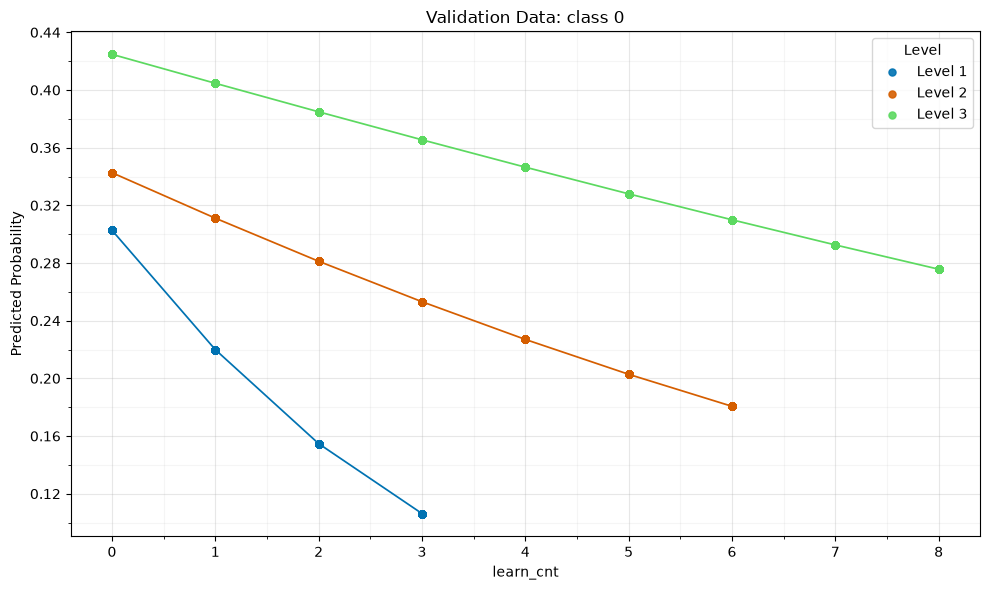

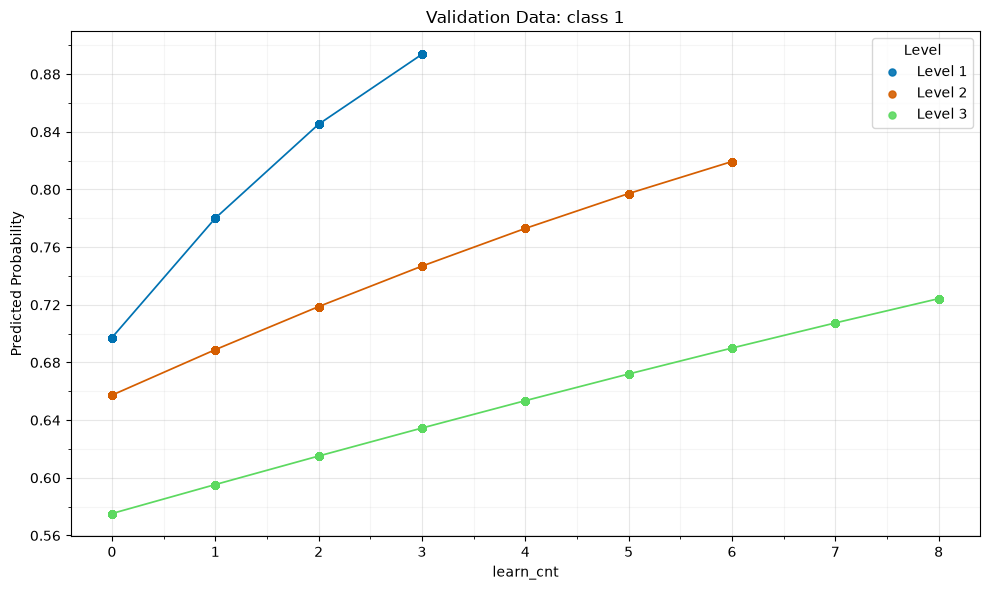

In [13]:
validation_result = training_results[CAPPED_DATASET_NAME]

validation_data = validation_result["X_test"].copy()
validation_data["a_t"] = validation_result["y_test"].to_numpy()

# Predicted probability of class 1 for every validation observation.
validation_data["model_probability"] = (
    validation_result["model"]
    .predict_proba(validation_data[FEATURE_COLUMNS])[:, 1]
)

# One row per level_t / learn_cnt combination in the validation set.
validation_combination_table = (
    validation_data
    .groupby(["level_t", "learn_cnt"], as_index=False)
    .agg(
        number_of_appearances=("a_t", "size"),
        empirical_success_rate=("a_t", "mean"),
        model_success_rate=("model_probability", "mean"),
    )
    .sort_values(["level_t", "learn_cnt"])
    .reset_index(drop=True)
)

display(validation_combination_table)

# ---------------------------------------------------------------------------
# Validation probability plots
# ---------------------------------------------------------------------------

levels = sorted(validation_data["level_t"].dropna().unique())
colours = {1: "#0072B2", 2: "#D55E00", 3: "#5CD960"}
class_columns = [
    ("probability_class_0", "Validation Data: class 0"),
    ("probability_class_1", "Validation Data: class 1"),
]

validation_probabilities = validation_result["model"].predict_proba(validation_data[FEATURE_COLUMNS])
validation_data["probability_class_0"] = validation_probabilities[:, 0]
validation_data["probability_class_1"] = validation_probabilities[:, 1]

def plot_validation_class(probability_column: str, title: str) -> None:
    fig, axis = plt.subplots(figsize=(10, 6))

    for level in levels:
        level_frame = validation_data.loc[
            validation_data["level_t"] == level,
            ["learn_cnt", probability_column]
        ]
        if level_frame.empty:
            continue

        level_frame = level_frame.sort_values("learn_cnt")
        plot_colour = colours.get(level)
        scatter_kwargs = {"s": 26, "alpha": 0.9, "label": f"Level {level}", "zorder": 3}
        line_kwargs = {"linestyle": "-", "linewidth": 1.25, "zorder": 2}
    
        if plot_colour is not None:
            scatter_kwargs["color"] = plot_colour
            line_kwargs["color"] = plot_colour

        axis.scatter(level_frame["learn_cnt"], level_frame[probability_column], **scatter_kwargs)
        axis.plot(level_frame["learn_cnt"], level_frame[probability_column], **line_kwargs)

    axis.set_xlabel("learn_cnt")
    axis.set_ylabel("Predicted Probability")
    axis.set_title(title)
    axis.xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
    axis.xaxis.set_minor_locator(AutoMinorLocator(2))
    axis.yaxis.set_major_locator(MaxNLocator(nbins=10))
    axis.yaxis.set_minor_locator(AutoMinorLocator(2))
    axis.grid(True, which="major", alpha=0.3)
    axis.grid(True, which="minor", alpha=0.12)
    axis.legend(title="Level")
    plt.tight_layout()
    plt.show()

for probability_column, title in class_columns:
    plot_validation_class(probability_column, title)


## 7. Manual Prediction

Use this section to test a single row manually.

In [14]:
example_dataset = CAPPED_DATASET_NAME
model = training_results[example_dataset]["model"]

custom_input = pd.DataFrame([{
    "level_t": 2,
    "learn_cnt": 7,
    # "a_t_minus_5": 0,
    # "a_t_minus_4": 0,
    # "a_t_minus_3": 0,
    # "a_t_minus_2": 0,
    # "a_t_minus_1": 0,
}])

print(f"Prediction for dataset: {example_dataset}")
display(custom_input)
print(f"Predicted class: {model.predict(custom_input)[0]}")
print(f"Predicted probability of class 1: {model.predict_proba(custom_input)[0, 1]:.4f}")


Prediction for dataset: obs100000MP_capped2000


,level_t,learn_cnt
0,2,7


Predicted class: 1
Predicted probability of class 1: 0.8397


## 8. How to Extend the Notebook

To add the lag columns later, change `USE_LAG_FEATURES` to `True`. That will include `a_t_minus_5` to `a_t_minus_1` in the model and in the capped dataset validation workflow.
